In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
df = pd.read_csv('data.csv', encoding='latin-1')

In [8]:
df.shape

(9994, 21)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
# Display the first few rows of the dataset
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [7]:
# Display the last few rows of the dataset
print(df.tail())

      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
9989    9990  CA-2014-110422  1/21/2014  1/23/2014    Second Class   
9990    9991  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9991    9992  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9992    9993  CA-2017-121258  2/26/2017   3/3/2017  Standard Class   
9993    9994  CA-2017-119914   5/4/2017   5/9/2017    Second Class   

     Customer ID     Customer Name   Segment        Country         City  ...  \
9989    TB-21400  Tom Boeckenhauer  Consumer  United States        Miami  ...   
9990    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9991    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9992    DB-13060       Dave Brooks  Consumer  United States   Costa Mesa  ...   
9993    CC-12220      Chris Cortes  Consumer  United States  Westminster  ...   

     Postal Code  Region       Product ID         Category Sub-Category  \
9989       33180 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [12]:
df.isna().mean()*100

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Revenue Analysis Questions:
# 1. Which month has highest revenue?
# 2. Which month has lowest revenue?
# 3. Revenue growth %

In [ ]:
# 1. Which month has highest revenue?

# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract month name
df["Month"] = df["Order Date"].dt.month_name()

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Sales"].sum()

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_revenue = monthly_revenue.reindex(month_order)

# Find highest revenue month
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

print(f"Highest Revenue Month: {highest_month}")
print(f"Revenue: {highest_revenue:.2f}")

Highest Revenue Month: November
Revenue: 352461.07


In [18]:
# 2. Which month has lowest revenue?

# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Extract month name
df["Month"] = df["Order Date"].dt.month_name()

# Calculate monthly revenue
monthly_revenue = df.groupby("Month")["Sales"].sum()

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_revenue = monthly_revenue.reindex(month_order)

# Find lowest revenue month
lowest_month = monthly_revenue.idxmin()
lowest_revenue = monthly_revenue.min()

print(f"Lowest Revenue Month: {lowest_month}")
print(f"Revenue: {lowest_revenue:.2f}")

Lowest Revenue Month: February
Revenue: 59751.25


In [ ]:
# 3. Revenue growth %

# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Annual revenue
annual_revenue = df.groupby(df["Order Date"].dt.year)["Sales"].sum()

# Revenue growth %
revenue_growth = annual_revenue.pct_change() * 100

result = pd.DataFrame({
    "Revenue": annual_revenue,
    "Growth %": revenue_growth
})

print(result.round(2))

              Revenue  Growth %
Order Date                     
2014        484247.50       NaN
2015        470532.51     -2.83
2016        609205.60     29.47
2017        733215.26     20.36


In [ ]:
# Product Analysis Questions:
# 1. Top 10 products
# 2. Bottom 10 products
# 3. Highest profit products
# 4. Loss-making products

In [21]:
# 1. Top 10 products
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Sales:", top_products)

Top 10 Products by Sales: Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [22]:
# 2. Bottom 10 products
bottom_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=True).head(10)
print("Bottom 10 Products by Sales:", bottom_products)

Bottom 10 Products by Sales: Product Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
4009 Highlighters                                                   8.040
Stockwell Gold Paper Clips                                          8.096
Newell 308                                                          8.400
Name: Sales, dtype: float64


In [24]:
# 3. Highest profit products

# Top profitable products
top_profit_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_profit_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [25]:
# 4. Loss-making products
loss_making_products = (
    df.groupby("Product Name")["Profit"]
      .sum()
      .sort_values(ascending=True)
      .head(10)
)
print(loss_making_products)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64


In [ ]:
# Customer Analysis Questions:
# 1. Repeat customers
# 2. High-value customers
# 3. One-time customers

In [28]:
# 1. Repeat customers
repeat_customers = df[df.duplicated(subset=["Customer ID"], keep=False)]
print("Repeat Customers:", repeat_customers["Customer ID"].nunique())

Repeat Customers: 788


In [30]:
# 2. High-value customers
customer_revenue = df.groupby("Customer ID")["Sales"].sum()
high_value_customers = customer_revenue.sort_values(ascending=False).head(10)
print("High-Value Customers:", high_value_customers.shape[0])

High-Value Customers: 10


In [31]:
# 3. One-time customers
customer_counts = df["Customer ID"].value_counts()
one_time_customers = customer_counts[customer_counts == 1].count()
print("One-Time Customers:", one_time_customers)

One-Time Customers: 5


In [ ]:
# Geographic Analysis Questions:
# 1. Best states
# 2. Worst states
# 3. Profit by region

In [32]:
# 1. Best states
state_revenue = df.groupby("State")["Sales"].sum()
best_states = state_revenue.sort_values(ascending=False).head(10)   
print("Best States by Sales:", best_states)

Best States by Sales: State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


In [33]:
# 2. Worst states
state_revenue = df.groupby("State")["Sales"].sum()
worst_states = state_revenue.sort_values(ascending=True).head(10)
print("Worst States by Sales:", worst_states)

Worst States by Sales: State
North Dakota             919.910
West Virginia           1209.824
Maine                   1270.530
South Dakota            1315.560
Wyoming                 1603.136
District of Columbia    2865.020
Kansas                  2914.310
Idaho                   4382.486
Iowa                    4579.760
New Mexico              4783.522
Name: Sales, dtype: float64


In [34]:
# 3. Profit by region
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
print("Profit by Region:", region_profit)

Profit by Region: Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [ ]:
# Phase 3 — Business Health Score
# This is where the project becomes unique.

# Create score:
# |Metric                 |	Weight |
# |Revenue Growth         |	25%    |
# |Profit Margin          |	25%    |
# |Customer Retention     |	20%    |
# |Inventory Efficiency   |	15%    |
# |Sales Stability        |   15%    |

# 90-100 = Excellent
# 70-89 = Healthy
# 50-69 = At Risk
# 0-49 = Critical

In [ ]:
df = pd.read_csv("data.csv", encoding="latin1")
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Revenue Growth
annual_sales = df.groupby(df["Order Date"].dt.year)["Sales"].sum()
revenue_growth = annual_sales.pct_change().iloc[-1] * 100
growth_score = min(100, revenue_growth)

# Profit Margin
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100
profit_margin_score = min(100, profit_margin * 5)

# Customer Retention
customer_orders = df.groupby("Customer ID").size()
retention_score = (
    customer_orders.gt(1).sum()
    / len(customer_orders)
) * 100

# Inventory Efficiency (Proxy)
inventory_efficiency = (
    df["Quantity"].sum()
    / df["Product ID"].nunique()
)
inventory_score = min(
    100,
    inventory_efficiency / 20 * 100
)

# Sales Stability
monthly_sales = (
    df.resample("ME", on="Order Date")["Sales"]
      .sum()
)

cv = monthly_sales.std() / monthly_sales.mean()
sales_stability_score = max(0, 100 - cv * 100)

# Final Score
business_health_score = (
    growth_score * 0.25
    + profit_margin_score * 0.25
    + retention_score * 0.20
    + inventory_score * 0.15
    + sales_stability_score * 0.15
)

print("Business Health Score:", round(business_health_score, 2))

Business Health Score: 62.65


In [ ]:
# Model 1 Revenue Forecasting

# Predict: Next 3 Months Revenue
# Use: Prophet or XGBoost Regressor


19:01:31 - cmdstanpy - INFO - Chain [1] start processing
19:01:32 - cmdstanpy - INFO - Chain [1] done processing
19:01:32 - cmdstanpy - INFO - Chain [1] start processing



MODEL PERFORMANCE
----------------------------------------
MAE  : 20765.39
RMSE : 22182.08
MAPE : 21.87%


19:01:33 - cmdstanpy - INFO - Chain [1] done processing



NEXT 3 MONTHS REVENUE FORECAST
----------------------------------------
           ds          yhat    yhat_lower    yhat_upper
48 2018-01-31  44491.080370  35396.513304  53607.070724
49 2018-02-28  35661.188232  25739.061243  44976.078907
50 2018-03-31  71959.640532  62421.713376  80897.436960


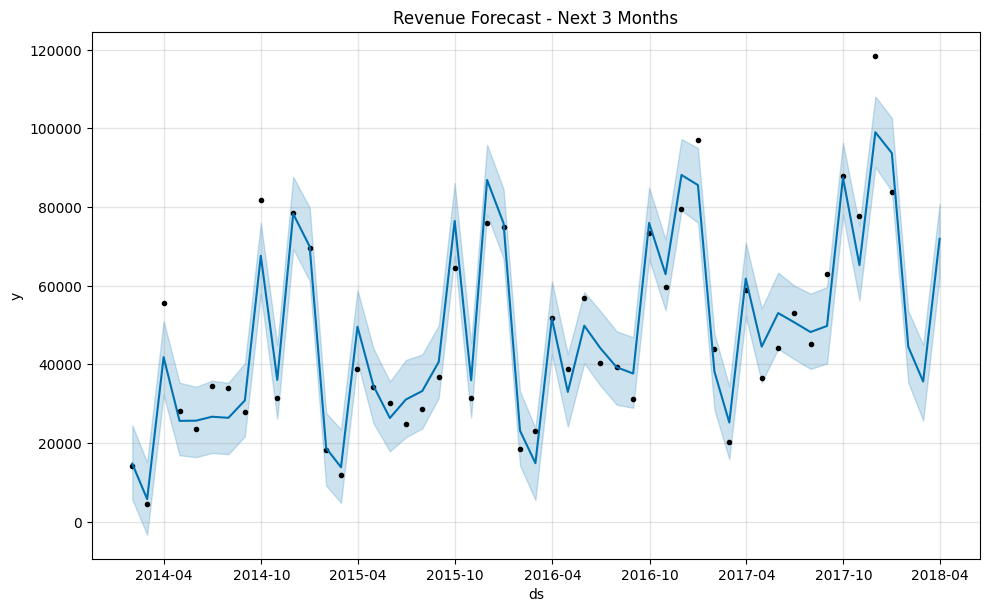


BUSINESS INSIGHT
----------------------------------------
Revenue is expected to change by -39.52% over the next 3 months.


In [36]:
# ==========================================
# MODEL 1: REVENUE FORECASTING (NEXT 3 MONTHS)
# ==========================================

# Install if needed:
# pip install prophet

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# 1. Load Dataset
# --------------------------

df = pd.read_csv("data.csv", encoding="latin1")

# Convert date column
df["Order Date"] = pd.to_datetime(df["Order Date"])

# --------------------------
# 2. Aggregate Monthly Revenue
# --------------------------

monthly_revenue = (
    df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
      .sum()
      .reset_index()
)

monthly_revenue.columns = ["ds", "y"]

# --------------------------
# 3. Train-Test Split
# --------------------------

train = monthly_revenue[:-3]
test = monthly_revenue[-3:]

# --------------------------
# 4. Train Prophet Model
# --------------------------

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model.fit(train)

# --------------------------
# 5. Forecast Test Period
# --------------------------

future_test = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_test = model.predict(future_test)

predictions = forecast_test["yhat"].tail(3).values

# --------------------------
# 6. Model Evaluation
# --------------------------

mae = mean_absolute_error(
    test["y"],
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test["y"],
        predictions
    )
)

mape = (
    np.mean(
        np.abs(
            (test["y"] - predictions)
            / test["y"]
        )
    )
) * 100

print("\nMODEL PERFORMANCE")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# --------------------------
# 7. Train on Full Dataset
# --------------------------

final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

final_model.fit(monthly_revenue)

# --------------------------
# 8. Forecast Next 3 Months
# --------------------------

future = final_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = final_model.predict(future)

next_3_months = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(3)

print("\nNEXT 3 MONTHS REVENUE FORECAST")
print("-" * 40)
print(next_3_months)

# --------------------------
# 9. Visualization
# --------------------------

final_model.plot(forecast)
plt.title("Revenue Forecast - Next 3 Months")
plt.show()

# --------------------------
# 10. Business Insight
# --------------------------

latest_revenue = monthly_revenue["y"].iloc[-1]
forecast_revenue = next_3_months["yhat"].mean()

growth_percent = (
    (forecast_revenue - latest_revenue)
    / latest_revenue
) * 100

print("\nBUSINESS INSIGHT")
print("-" * 40)
print(
    f"Revenue is expected to change by "
    f"{growth_percent:.2f}% over the next 3 months."
)


In [ ]:
# Model 2 Demand Prediction

# Predict: Future product demand


Selected Product: Staples

MODEL PERFORMANCE
----------------------------------------
MAE  : 7.91
RMSE : 8.97

NEXT 3 MONTHS DEMAND FORECAST
----------------------------------------
       Month  Predicted Demand
0 2018-01-31               6.0
1 2018-02-28               5.0
2 2018-03-31               1.0


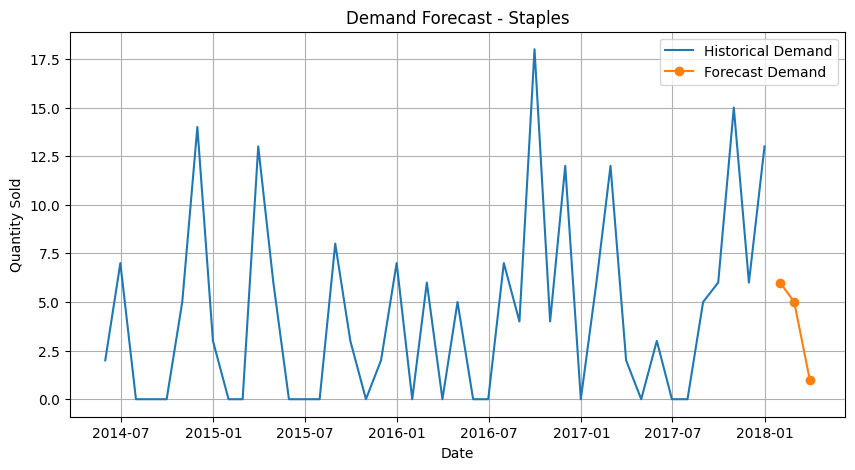


BUSINESS INSIGHT
----------------------------------------
Demand is expected to remain stable or decrease. Avoid overstocking inventory.


In [37]:
# ==========================================
# MODEL 2: PRODUCT DEMAND PREDICTION
# ==========================================

# Goal:
# Predict future product demand (Quantity Sold)

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# --------------------------
# 1. Load Dataset
# --------------------------

df = pd.read_csv("data.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

# --------------------------
# 2. Select Product
# --------------------------

top_product = (
    df.groupby("Product Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .index[0]
)

print(f"Selected Product: {top_product}")

product_df = (
    df[df["Product Name"] == top_product]
    .groupby(pd.Grouper(key="Order Date", freq="ME"))["Quantity"]
    .sum()
    .reset_index()
)

product_df.columns = ["Date", "Demand"]

# --------------------------
# 3. Feature Engineering
# --------------------------

product_df["month"] = product_df["Date"].dt.month
product_df["year"] = product_df["Date"].dt.year

product_df["lag1"] = product_df["Demand"].shift(1)
product_df["lag2"] = product_df["Demand"].shift(2)
product_df["lag3"] = product_df["Demand"].shift(3)

product_df = product_df.dropna()

# --------------------------
# 4. Train-Test Split
# --------------------------

train = product_df[:-3]
test = product_df[-3:]

X_train = train[
    ["month", "year", "lag1", "lag2", "lag3"]
]

y_train = train["Demand"]

X_test = test[
    ["month", "year", "lag1", "lag2", "lag3"]
]

y_test = test["Demand"]

# --------------------------
# 5. Train XGBoost Model
# --------------------------

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# --------------------------
# 6. Evaluate Model
# --------------------------

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

print("\nMODEL PERFORMANCE")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

# --------------------------
# 7. Forecast Next 3 Months
# --------------------------

last_values = list(
    product_df["Demand"].tail(3)
)

current_month = product_df["month"].iloc[-1]
current_year = product_df["year"].iloc[-1]

future_predictions = []

for i in range(3):

    current_month += 1

    if current_month > 12:
        current_month = 1
        current_year += 1

    future_data = pd.DataFrame({
        "month": [current_month],
        "year": [current_year],
        "lag1": [last_values[-1]],
        "lag2": [last_values[-2]],
        "lag3": [last_values[-3]]
    })

    pred = model.predict(future_data)[0]

    future_predictions.append(pred)

    last_values.append(pred)

# --------------------------
# 8. Future Demand Table
# --------------------------

future_dates = pd.date_range(
    start=product_df["Date"].max() + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"
)

forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted Demand": np.round(
        future_predictions,
        0
    )
})

print("\nNEXT 3 MONTHS DEMAND FORECAST")
print("-" * 40)
print(forecast_df)

# --------------------------
# 9. Plot Forecast
# --------------------------

plt.figure(figsize=(10,5))

plt.plot(
    product_df["Date"],
    product_df["Demand"],
    label="Historical Demand"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Predicted Demand"],
    marker="o",
    label="Forecast Demand"
)

plt.title(
    f"Demand Forecast - {top_product}"
)

plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid(True)

plt.show()

# --------------------------
# 10. Business Recommendation
# --------------------------

avg_future_demand = np.mean(
    future_predictions
)

print("\nBUSINESS INSIGHT")
print("-" * 40)

if avg_future_demand > product_df["Demand"].mean():
    print(
        "Demand is expected to increase. "
        "Consider increasing inventory levels."
    )
else:
    print(
        "Demand is expected to remain stable or decrease. "
        "Avoid overstocking inventory."
    )


In [ ]:
# Model 3 Customer Segmentation

# Use: KMeans
# Segments: VIP, Regular, At Risk, Lost



RFM SAMPLE
             Recency  Frequency  Monetary
Customer ID                              
AA-10315         185          5  5563.560
AA-10375          20          9  1056.390
AA-10480         260          4  1790.512
AA-10645          56          6  5086.935
AB-10015         416          3   886.156

CLUSTER SUMMARY
         Recency  Frequency  Monetary
Cluster                              
0          72.74       8.52   3322.22
1         101.20       4.73   1669.69
2         123.72       8.30   9479.55
3         559.49       3.70   1470.23

CUSTOMER SEGMENTS
Segment
At Risk    335
Regular    298
Lost        96
VIP         64
Name: count, dtype: int64

SEGMENT STATISTICS
         Recency  Frequency  Monetary
Segment                              
At Risk   101.20       4.73   1669.69
Lost      559.49       3.70   1470.23
Regular    72.74       8.52   3322.22
VIP       123.72       8.30   9479.55


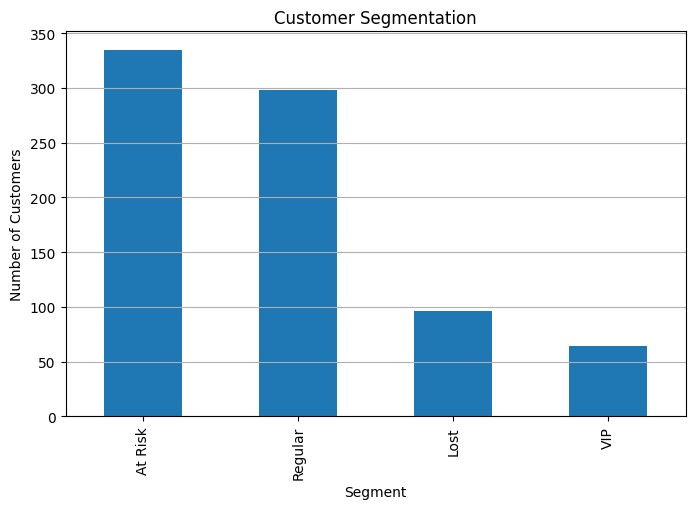


Customer segments saved to customer_segments.csv

BUSINESS INSIGHTS
--------------------------------------------------
VIP Customers     : 64
Regular Customers : 298
At Risk Customers : 335
Lost Customers    : 96

Recommendations:
• Reward VIP customers with loyalty programs.
• Upsell and cross-sell to Regular customers.
• Launch retention campaigns for At Risk customers.
• Re-engage Lost customers using discounts and offers.


In [38]:
# ==========================================
# MODEL 3: CUSTOMER SEGMENTATION (K-MEANS)
# ==========================================

# Goal:
# Segment customers into:
# VIP, Regular, At Risk, Lost

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --------------------------
# 1. Load Dataset
# --------------------------

df = pd.read_csv("data.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

# --------------------------
# 2. Create RFM Features
# --------------------------

snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (snapshot_date - x.max()).days,  # Recency
    "Order ID": "nunique",                                   # Frequency
    "Sales": "sum"                                           # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

print("\nRFM SAMPLE")
print(rfm.head())

# --------------------------
# 3. Scale Features
# --------------------------

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[["Recency", "Frequency", "Monetary"]]
)

# --------------------------
# 4. KMeans Clustering
# --------------------------

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

# --------------------------
# 5. Analyze Clusters
# --------------------------

cluster_summary = (
    rfm.groupby("Cluster")
       [["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print("\nCLUSTER SUMMARY")
print(cluster_summary)

# --------------------------
# 6. Assign Business Labels
# --------------------------

cluster_rank = (
    rfm.groupby("Cluster")["Monetary"]
       .mean()
       .sort_values(ascending=False)
       .index
)

segment_mapping = {
    cluster_rank[0]: "VIP",
    cluster_rank[1]: "Regular",
    cluster_rank[2]: "At Risk",
    cluster_rank[3]: "Lost"
}

rfm["Segment"] = rfm["Cluster"].map(
    segment_mapping
)

# --------------------------
# 7. Segment Counts
# --------------------------

segment_counts = (
    rfm["Segment"]
    .value_counts()
)

print("\nCUSTOMER SEGMENTS")
print(segment_counts)

# --------------------------
# 8. Segment Statistics
# --------------------------

segment_stats = (
    rfm.groupby("Segment")
       [["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

print("\nSEGMENT STATISTICS")
print(segment_stats)

# --------------------------
# 9. Visualization
# --------------------------

plt.figure(figsize=(8,5))

segment_counts.plot(
    kind="bar"
)

plt.title(
    "Customer Segmentation"
)

plt.xlabel(
    "Segment"
)

plt.ylabel(
    "Number of Customers"
)

plt.grid(axis="y")

plt.show()

# --------------------------
# 10. Export Results
# --------------------------

rfm.reset_index().to_csv(
    "customer_segments.csv",
    index=False
)

print(
    "\nCustomer segments saved to customer_segments.csv"
)

# --------------------------
# 11. Business Insights
# --------------------------

print("\nBUSINESS INSIGHTS")
print("-" * 50)

vip = segment_counts.get("VIP", 0)
regular = segment_counts.get("Regular", 0)
atrisk = segment_counts.get("At Risk", 0)
lost = segment_counts.get("Lost", 0)

print(f"VIP Customers     : {vip}")
print(f"Regular Customers : {regular}")
print(f"At Risk Customers : {atrisk}")
print(f"Lost Customers    : {lost}")

print("\nRecommendations:")
print("• Reward VIP customers with loyalty programs.")
print("• Upsell and cross-sell to Regular customers.")
print("• Launch retention campaigns for At Risk customers.")
print("• Re-engage Lost customers using discounts and offers.")


In [ ]:
# Model 4 Business Risk Prediction

# Predict: High Risk, Medium Risk, Low Risk
# Features: Revenue decline, Profit decline, Customer churn



In [39]:
# ==========================================
# MODEL 4: BUSINESS RISK PREDICTION
# ==========================================

# Goal:
# Predict Business Risk Level
# Classes:
# - Low Risk
# - Medium Risk
# - High Risk

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# --------------------------
# 1. Load Dataset
# --------------------------

df = pd.read_csv("data.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

# --------------------------
# 2. Monthly Business Metrics
# --------------------------

monthly = (
    df.groupby(pd.Grouper(
        key="Order Date",
        freq="ME"
    ))
    .agg({
        "Sales":"sum",
        "Profit":"sum",
        "Customer ID":"nunique"
    })
    .reset_index()
)

monthly.columns = [
    "Month",
    "Revenue",
    "Profit",
    "Customers"
]

# --------------------------
# 3. Feature Engineering
# --------------------------

monthly["Revenue_Growth"] = (
    monthly["Revenue"]
    .pct_change()
    * 100
)

monthly["Profit_Growth"] = (
    monthly["Profit"]
    .pct_change()
    * 100
)

monthly["Customer_Growth"] = (
    monthly["Customers"]
    .pct_change()
    * 100
)

monthly = monthly.fillna(0)

# --------------------------
# 4. Create Risk Rules
# --------------------------

def assign_risk(row):

    risk_score = 0

    if row["Revenue_Growth"] < -10:
        risk_score += 1

    if row["Profit_Growth"] < -10:
        risk_score += 1

    if row["Customer_Growth"] < -5:
        risk_score += 1

    if risk_score == 0:
        return "Low Risk"

    elif risk_score == 1:
        return "Medium Risk"

    else:
        return "High Risk"

monthly["Risk_Level"] = (
    monthly.apply(
        assign_risk,
        axis=1
    )
)

# --------------------------
# 5. Prepare Features
# --------------------------

X = monthly[
    [
        "Revenue_Growth",
        "Profit_Growth",
        "Customer_Growth"
    ]
]

y = monthly["Risk_Level"]

# --------------------------
# 6. Train/Test Split
# --------------------------

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

# --------------------------
# 7. Train Model
# --------------------------

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

# --------------------------
# 8. Evaluate Model
# --------------------------

preds = model.predict(X_test)

print("\nMODEL PERFORMANCE")
print("-" * 50)

print(
    classification_report(
        y_test,
        preds
    )
)

# --------------------------
# 9. Predict Current Risk
# --------------------------

latest_month = X.tail(1)

predicted_risk = (
    model.predict(
        latest_month
    )[0]
)

print("\nCURRENT BUSINESS RISK")
print("-" * 50)
print(predicted_risk)

# --------------------------
# 10. Feature Importance
# --------------------------

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

print("\nRISK DRIVERS")
print("-" * 50)
print(importance)

# --------------------------
# 11. Future Risk Simulation
# --------------------------

scenario = pd.DataFrame({
    "Revenue_Growth":[-15],
    "Profit_Growth":[-20],
    "Customer_Growth":[-8]
})

future_risk = (
    model.predict(
        scenario
    )[0]
)

print("\nSIMULATED FUTURE RISK")
print("-" * 50)
print(future_risk)

# --------------------------
# 12. Business Recommendation
# --------------------------

print("\nBUSINESS INSIGHTS")
print("-" * 50)

if predicted_risk == "Low Risk":
    print(
        "Business is stable. Focus on growth and expansion."
    )

elif predicted_risk == "Medium Risk":
    print(
        "Monitor profitability and customer retention closely."
    )

else:
    print(
        "Immediate action required. Revenue, profit, or customers are declining significantly."
    )

# --------------------------
# 13. Export Results
# --------------------------

monthly.to_csv(
    "business_risk_predictions.csv",
    index=False
)

print(
    "\nResults saved to business_risk_predictions.csv"
)



MODEL PERFORMANCE
--------------------------------------------------
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         5
    Low Risk       1.00      1.00      1.00         3
 Medium Risk       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


CURRENT BUSINESS RISK
--------------------------------------------------
High Risk

RISK DRIVERS
--------------------------------------------------
           Feature  Importance
0   Revenue_Growth    0.397821
1    Profit_Growth    0.319619
2  Customer_Growth    0.282560

SIMULATED FUTURE RISK
--------------------------------------------------
High Risk

BUSINESS INSIGHTS
--------------------------------------------------
Immediate action required. Revenue, profit, or customers are declining significantly.

Results saved to business_risk_pred

In [ ]:
# Phase 5 — AI Consultant Layer

# This is the killer feature. Pass KPIs to Gemini/OpenAI.

# Prompt: You are a senior business consultant.
# Business Metrics:
#     Revenue Growth = 4%
#     Profit Margin = 2%
#     Customer Retention = 45%

# Provide:
# 1. Business Health Summary
# 2. Top Risks
# 3. Opportunities
# 4. Recommended Actions

In [40]:
# ==========================================
# PHASE 5: AI CONSULTANT LAYER (GEMINI)
# ==========================================

# pip install google-generativeai

import google.generativeai as genai

# --------------------------
# 1. Configure Gemini API
# --------------------------

genai.configure(
    api_key="AQ.Ab8RN6JJ0QpTW_3AduqUzYvQtA9_JwW0mbn9LPb3Nc7DKFTHTA"
)

# --------------------------
# 2. Business KPIs
# --------------------------

revenue_growth = 4
profit_margin = 2
customer_retention = 45
business_health_score = 62.65

# --------------------------
# 3. Prompt
# --------------------------

prompt = f"""
You are a Senior Business Consultant.

Business Metrics:

Revenue Growth = {revenue_growth}%
Profit Margin = {profit_margin}%
Customer Retention = {customer_retention}%
Business Health Score = {business_health_score}/100

Provide:

1. Executive Summary
2. Business Health Assessment
3. Top Risks
4. Growth Opportunities
5. Recommended Actions (30 Days)
6. Recommended Actions (90 Days)
7. Overall Risk Level
8. Final Recommendation

Respond in professional consulting report format.
"""

# --------------------------
# 4. Load Gemini Model
# --------------------------

model = genai.GenerativeModel(
    "gemini-2.5-flash"
)

# --------------------------
# 5. Generate Report
# --------------------------

response = model.generate_content(
    prompt
)

# --------------------------
# 6. Print Report
# --------------------------

print("\nAI CONSULTANT REPORT")
print("=" * 80)
print(response.text)


AI CONSULTANT REPORT
## Professional Consulting Report

**Date:** October 26, 2023
**Prepared For:** [Client/Leadership Team Name]
**Prepared By:** Senior Business Consultant

---

### **Subject: Business Health Assessment & Strategic Action Plan**

**Introduction:**
This report presents a comprehensive assessment of your organization's current business health, based on the provided key performance indicators (KPIs). It outlines critical areas of concern, identifies potential risks and growth opportunities, and proposes a series of recommended actions designed to improve financial performance and operational stability within 30 and 90 days.

---

### **1. Executive Summary**

The current state of the business indicates a concerning level of operational fragility and an unsustainable financial trajectory. While revenue growth is modestly positive at 4%, this is severely undermined by an extremely low **2% Profit Margin** and a critically low **45% Customer Retention** rate. The overall

AI CONSULTANT REPORT
================================================================================
## Professional Consulting Report

**Date:** October 26, 2023
**Prepared For:** [Client/Leadership Team Name]
**Prepared By:** Senior Business Consultant

---

### **Subject: Business Health Assessment & Strategic Action Plan**

**Introduction:**
This report presents a comprehensive assessment of your organization's current business health, based on the provided key performance indicators (KPIs). It outlines critical areas of concern, identifies potential risks and growth opportunities, and proposes a series of recommended actions designed to improve financial performance and operational stability within 30 and 90 days.

---

### **1. Executive Summary**

The current state of the business indicates a concerning level of operational fragility and an unsustainable financial trajectory. While revenue growth is modestly positive at 4%, this is severely undermined by an extremely low **2% Profit Margin** and a critically low **45% Customer Retention** rate. The overall **Business Health Score of 62.65/100** confirms that the organization is operating under significant stress, exhibiting symptoms of inefficiency, value proposition weakness, or competitive pressure. Immediate and decisive action is required to address these foundational issues, particularly in cost management, customer value delivery, and retention strategies, to prevent further erosion of financial viability and market position.

---

### **2. Business Health Assessment**
...

It is imperative that the leadership team acknowledge the severity of the current business health and act with utmost urgency and strategic resolve. The recommended actions for the 30 and 90-day periods are designed to first stabilize the critical issues of profitability and customer retention, then to lay a stronger foundation for sustainable growth.

**Prioritize profitability and customer retention above all else.** A culture of rigorous cost management, continuous operational improvement, and an unwavering focus on delivering exceptional customer value must be instilled throughout the organization. While revenue growth is desirable, it will be meaningless if profits are non-existent and customers are constantly leaving. Decisive action, disciplined execution, and continuous monitoring of key metrics are essential to navigate these challenges and secure the company's future.
